**1.  Suppose an exam is to be given to students at a local college. To test its validity, the exam is administered to a sample of 10 students, and the scores are: 65, 70, 68, 73, 75, 80, 85, 78, 90, 100. We will estimate the 95% confidence interval for the mean of the population (i.e., the expected mean for a large number of students) using two different methods:**

(a) Calculate the sample mean and standard deviation of this set. Then use the formula to calculate the confidence interval.

In [15]:
import numpy as np

data = np.array([65, 70, 68, 73, 75, 80, 85, 78, 90, 100])

mean = np.mean(data)
sd = np.std(data)
print(f'Mean: {mean}\nStandard Deviation: {sd:.2f}')

t= 2.262
n = 10
r = ((t)*(sd/(n**0.5)))

low_conf_int = (mean - r)
hi_conf_int = (mean + r)
print(f'95% Confidence Interval: [{low_conf_int:.2f}, {hi_conf_int:.2f}]')


Mean: 78.4
Standard Deviation: 10.23
95% Confidence Interval: [71.08, 85.72]


**(b) Construct 40 bootstrapped samples of the data. Calculate the mean of each sample, and use this set of means to estimate the 95% confidence interval for the mean of the population**

In [14]:

bootstrapped_stats = []

for i in range(40):
    sample = np.random.choice(data, size=len(data), replace=True)
    mean = np.mean(sample)
    bootstrapped_stats.append(mean)

bootstrapped_stats = np.array(bootstrapped_stats)
lower_percentile = (100 - 95) / 2
upper_percentile = 100 - lower_percentile
ci_lower = np.percentile(bootstrapped_stats, lower_percentile)
ci_upper = np.percentile(bootstrapped_stats, upper_percentile)

print(f"95% Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}]")

95% Confidence Interval: [72.59, 85.18]


**(c) Which method would you choose to estimate the confidence interval for this use case. Explain why you believe your chosen method is more reliable?**

This sample is small, so I would use the bootstrapping method. Since we don't know if the exam scores follow a normal distribution, resampling the data using bootstrapping will create a better distribution of the mean, giving a more reliable confidence interval.

**2. Using the same 10 exam scores as in question 1, we will use cross-validation to estimate the prediction error of an exam score on new (holdout) data.**

**(a) Randomly assign each score into one of 5 subsets, each containing only two scores.**

In [16]:
import random

random.shuffle(data)

# Split into 5 subsets of 2 scores each
subsets = [data[i:i+2] for i in range(0, len(data), 2)]

# Print the subsets
for idx, subset in enumerate(subsets, start=1):
    print(f"Subset {idx}: {subset}")

Subset 1: [90 75]
Subset 2: [73 70]
Subset 3: [68 80]
Subset 4: [100  85]
Subset 5: [78 65]


**(b) For each of the five subsets created, we have 8 associated “training” scores and 2 “validation” scores. For each of the 5 training sets, calculate the average score.**

In [27]:
training_means = []

# Calculate training set mean for each validation subset
for idx, val_set in enumerate(subsets, start=1):
    # Training set = all data not in the current validation subset
    training_set = np.setdiff1d(data, val_set)
    
    # Compute mean of the training set
    mean_train = np.mean(training_set)
    training_means.append(mean_train)
    
    print(f"Mean of Training Set {idx}: {mean_train:.2f}")

Mean of Training Set 1: 77.38
Mean of Training Set 2: 80.12
Mean of Training Set 3: 79.50
Mean of Training Set 4: 74.88
Mean of Training Set 5: 80.12


**(c) If we treat each of the 5 calculated average scores as a prediction, what is the mean absolute error computed on each associated validation set (each containing the 2 remaining elements)?**

In [28]:
mae_values = []
for val_set, train_mean in zip(subsets, training_means):
    mae = np.mean(np.abs(val_set - train_mean))
    mae_values.append(mae)
    print(f"Subset: {val_set}, MAE: {mae:.2f}")

Subset: [90 75], MAE: 7.50
Subset: [73 70], MAE: 8.62
Subset: [68 80], MAE: 6.00
Subset: [100  85], MAE: 17.62
Subset: [78 65], MAE: 8.62


**(d) Compute the average mean absolute error across the 5 cross-validation folds**

In [30]:
avg_mae = np.mean(mae_values)
print(f"Average MAE: {avg_mae:.2f}")

Average MAE: 9.68


**(e) Suppose we conduct this exam again, and for simplicity let’s assume we get exactly the same scores. If we had used the average exam score to predict the “new” exam scores, what would the mean absolute error be on this “new” set?**

In [36]:
score_difs = []

for i in data:
    dif = abs(i - mean)
    score_difs.append(dif)

tot = np.array(score_difs).sum()
new_mae = tot/10
print(f"Mean Absolute Error on 'new' exam: {new_mae:.2f}")

Mean Absolute Error on 'new' exam: 8.28


**3. This problem involves the OJ data, which is part of the ISLP package. We will use classification trees to predict the value of Purchase.**

In [58]:
import pandas as pd
from ISLP import load_data
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)

#load dataset
OJ = load_data('OJ')

**(a) Create a training set contain a random sample of 800 observations, and a test set containing the remaining observations. You will also need to convert the Store7 column to numeric.**

In [56]:
OJ['Store7'] = OJ['Store7'].map({'Yes': 1, 'No': 0})

train, test = train_test_split(OJ, train_size=800, random_state=42)

**(b) Fit a single tree to the training data, with Purchase as the response and the other variables as predictors. Use 6 as the maximum number of leaf nodes. Produce a confusion matrix and state the total misclassification error on training data.**

In [57]:
y_train = train['Purchase']
X_train = train.drop('Purchase', axis=1)
y_test = test['Purchase']
X_test = test.drop('Purchase', axis=1)

tree1 = DTC(max_leaf_nodes=6)
tree1.fit(X_train, y_train)

pred_train = tree1.predict(X_train)
conf_train = confusion_matrix(y_train, pred_train)
train_error = 1 - accuracy_score(y_train, pred_train)

print("Training confusion matrix")
print(conf_train)
print(f'Training error: {train_error}')

Training confusion matrix
[[451  43]
 [ 82 224]]
Training error: 0.15625


**(c) Create a plot of the tree and interpret the results.**

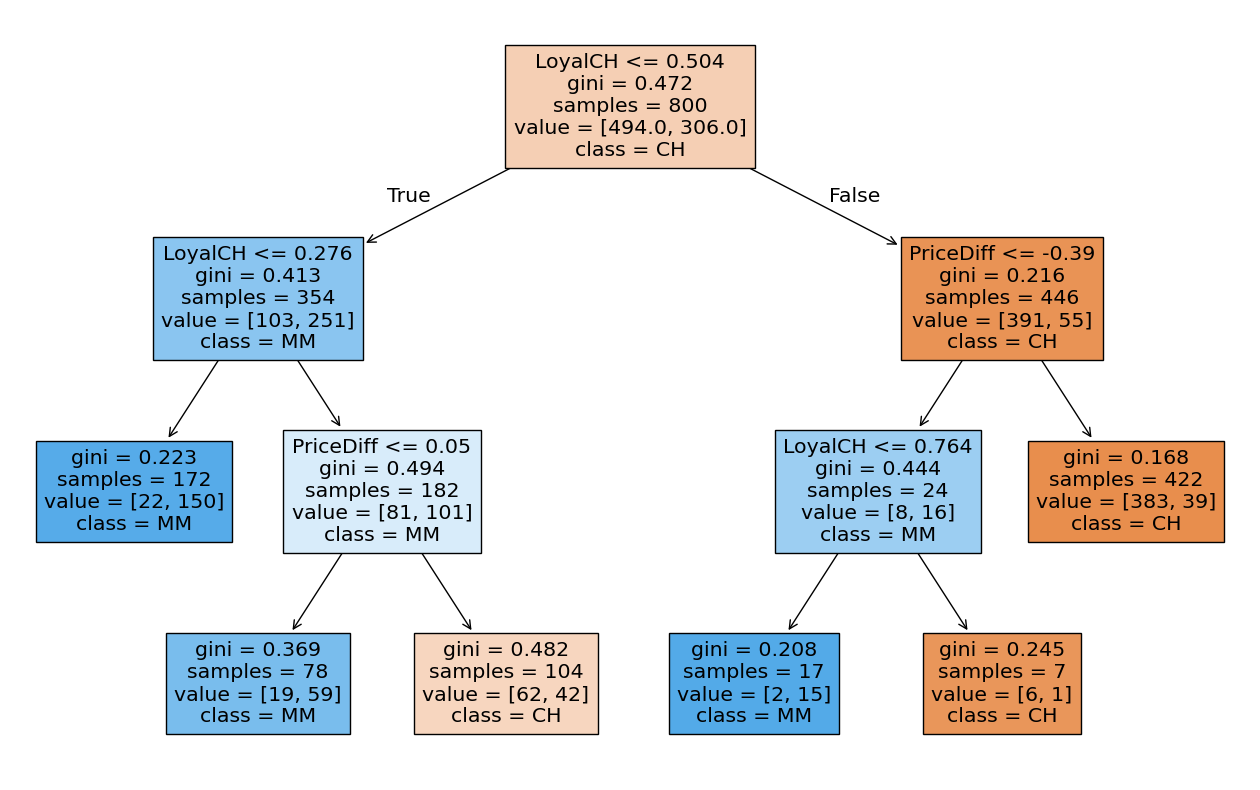

In [59]:
plt.figure(figsize=(16,10))
plot_tree(tree1, feature_names=X_train.columns, class_names=['CH', 'MM'], filled=True)
plt.show()

- The model shows that customer loyalty to CH is the strongest predictor of purchase type.
- Low loyalty values generally indicate MM purchases, while high loyalty values indicate CH purchases.
- Price differences further refine predictions — when CH is much cheaper, CH purchases dominate.
- Overall, the decision tree reveals that loyalty and relative pricing are key drivers of customer choice.